# Упражнения <a id='tasks'></a>

Необходимо изучить библиотеку [tslearn](https://tslearn.readthedocs.io/en/stable/).

1. Взять выбранные для лабы 14 набор(ы) данных. 

3. Попробовать все методы классификации и регрессии, описанные в блоноте 14 aeon:
    Distance-based 
    Свертки (модели семейства Rocket и Hydra)
    Feature-based
    Deep Learning

    Для каждого подхода обучть не менее 3х разных моделей для классификации и регрессии.
    
     
    

In [125]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from tslearn.neighbors import KNeighborsTimeSeriesClassifier, KNeighborsTimeSeriesRegressor
from tslearn.svm import TimeSeriesSVC, TimeSeriesSVR
from tslearn.neural_network import TimeSeriesMLPClassifier, TimeSeriesMLPRegressor
from tslearn.shapelets import LearningShapelets
from tslearn.preprocessing import TimeSeriesScalerMinMax, TimeSeriesScalerMeanVariance

from aeon.datasets import load_classification, load_regression


In [ ]:
def convert_aeon_to_tslearn(X):
    """Конвертация формата aeon (n, 1, t) -> tslearn (n, t, 1)"""
    if X.ndim == 3 and X.shape[1] == 1:
        return np.moveaxis(X, 1, -1)
    return X

def extract_statistical_features(X):
    """Извлечение статистики + признаков динамики"""
    n_samples = len(X)
    X_flat = X.reshape(n_samples, -1)
    
    stats = np.column_stack([
        np.mean(X_flat, axis=1),
        np.std(X_flat, axis=1),
        np.min(X_flat, axis=1),
        np.max(X_flat, axis=1),
        np.median(X_flat, axis=1),
    ])

    X_diff = np.diff(X, axis=1) 
    X_diff_flat = X_diff.reshape(n_samples, -1)
    
    dynamics = np.column_stack([
        np.mean(X_diff_flat, axis=1),
        np.std(X_diff_flat, axis=1),
        np.max(X_diff_flat, axis=1),
        np.min(X_diff_flat, axis=1),
        X_flat[:, -1] - X_flat[:, 0],
    ])
    
    tail = X[:, -5:, :].reshape(n_samples, -1)
    
    return np.hstack([stats, dynamics, tail])

In [29]:
X_cls, y_cls = load_classification('BeetleFly')
X_reg, y_reg = load_regression('Covid3Month')

print(f"Классификация: {X_cls.shape}, классы: {np.unique(y_cls)}")
print(f"Регрессия: {X_reg.shape}, диапазон: [{y_reg.min():.2f}, {y_reg.max():.2f}]")

Классификация: (40, 1, 512), классы: ['1' '2']
Регрессия: (201, 1, 84), диапазон: [0.00, 0.18]


In [30]:
X_cls_ts = convert_aeon_to_tslearn(X_cls)
X_reg_ts = convert_aeon_to_tslearn(X_reg)

X_cls_train, X_cls_test, y_cls_train, y_cls_test = train_test_split(
    X_cls_ts, y_cls, test_size=0.3, random_state=42, stratify=y_cls)
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg_ts, y_reg, test_size=0.3, random_state=42)

In [133]:
scaler_cls = TimeSeriesScalerMinMax()
scaler_reg = TimeSeriesScalerMinMax()

X_cls_train_s = scaler_cls.fit_transform(X_cls_train)
X_cls_test_s = scaler_cls.transform(X_cls_test)

X_reg_train_s = scaler_reg.fit_transform(X_reg_train)
X_reg_test_s = scaler_reg.transform(X_reg_test)

In [139]:
distance_cls = {}

print("Классификация")
for name, metric in [('KNN-DTW', 'dtw'), 
                      ('KNN-Euclidean', 'euclidean'), 
                      ('KNN-SoftDTW', 'softdtw')]:
    try:
        model = KNeighborsTimeSeriesClassifier(n_neighbors=3, metric=metric)
        model.fit(X_cls_train_s, y_cls_train)
        y_pred = model.predict(X_cls_test_s)
        acc = accuracy_score(y_cls_test, y_pred)
        distance_cls[name] = acc
        print(f"  {name:18s} → Accuracy: {acc:.4f}")
    except Exception as e:
        print(f"  {name:18s} → Error: {str(e)[:50]}")
        distance_cls[name] = None

distance_reg = {}

print("Регрессия")
for name, metric in [('KNN-DTW', 'dtw'), 
                      ('KNN-Euclidean', 'euclidean'), 
                      ('KNN-SoftDTW', 'softdtw')]:
    try:
        model = KNeighborsTimeSeriesRegressor(n_neighbors=10, metric=metric)
        model.fit(X_reg_train, y_reg_train)
        y_pred = model.predict(X_reg_test_s)
        
        mse = mean_squared_error(y_reg_test, y_pred)
        r2 = r2_score(y_reg_test, y_pred)
        mape = mean_absolute_percentage_error(y_reg_test, y_pred)
        
        distance_reg[name] = {'MSE': mse, 'R2': r2, 'MAPE': mape}
        print(f"  {name:18s} → MSE: {mse:.4f}, R²: {r2:.4f}, MAPE: {mape:.4f}")
    except Exception as e:
        print(f"  {name:18s} → Error: {str(e)[:50]}")
        distance_reg[name] = None

Классификация
  KNN-DTW            → Accuracy: 0.8333
  KNN-Euclidean      → Accuracy: 0.7500
  KNN-SoftDTW        → Accuracy: 0.8333
Регрессия
  KNN-DTW            → MSE: 0.0026, R²: -0.2181, MAPE: 52111495894917.5234
  KNN-Euclidean      → MSE: 0.0024, R²: -0.0892, MAPE: 49025271050396.5391
  KNN-SoftDTW        → MSE: 0.0022, R²: -0.0027, MAPE: 46486390973923.4922


In [ ]:
feature_cls = {}

shapelet_configs = [
    ('Shapelets-2x32', {2: 32}),
    ('Shapelets-4x16', {4: 16}), 
    ('Shapelets-1x64', {1: 64}),
    ('Shapelets-mixed', {10: 10, 5: 20, 3: 30}),
]

print("Классификация (Shapelets)")
for name, n_shapelets in shapelet_configs:
    try:
        model = LearningShapelets(n_shapelets_per_size=n_shapelets, max_iter=200, batch_size=32, random_state=42)
        model.fit(X_cls_train_s, y_cls_train)
        y_pred = model.predict(X_cls_test_s)
        acc = accuracy_score(y_cls_test, y_pred)
        feature_cls[name] = acc
        print(f"  {name:18s} → Accuracy: {acc:.4f}")
    except Exception as e:
        print(f"  {name:18s} → Error: {str(e)[:50]}")
        feature_cls[name] = None

feature_reg = {}

X_reg_train_feat = extract_statistical_features(X_reg_train_s)
X_reg_test_feat = extract_statistical_features(X_reg_test_s)

print("Регрессия (Features)")
for name, regressor in [('Stats+Ridge', Ridge(alpha=1.0)), 
                         ('Stats+Lasso', Lasso(alpha=0.1, max_iter=200)),
                         ('Stats+RF', RandomForestRegressor(n_estimators=50, random_state=42))]:
    try:
        regressor.fit(X_reg_train_feat, y_reg_train)
        y_pred = regressor.predict(X_reg_test_feat)
        
        mse = mean_squared_error(y_reg_test, y_pred)
        r2 = r2_score(y_reg_test, y_pred)
        mape = mean_absolute_percentage_error(y_reg_test, y_pred)
        
        feature_reg[name] = {'MSE': mse, 'R2': r2, 'MAPE': mape}
        print(f"  {name:18s} → MSE: {mse:.4f}, R²: {r2:.4f}, MAPE: {mape:.4f}")
    except Exception as e:
        print(f"  {name:18s} → Error: {str(e)[:50]}")
        feature_reg[name] = None

Классификация (Shapelets)
  Shapelets-2x32     → Accuracy: 0.5833
  Shapelets-4x16     → Accuracy: 0.3333
  Shapelets-1x64     → Accuracy: 0.5833
  Shapelets-mixed    → Accuracy: 0.4167
Регрессия (Features)
  Stats+Ridge        → MSE: 0.0021, R²: 0.0114, MAPE: 36764254095395.3906
  Stats+Lasso        → MSE: 0.0022, R²: -0.0264, MAPE: 44384062792053.0469
  Stats+RF           → MSE: 0.0026, R²: -0.2037, MAPE: 44410449066112.7891


In [ ]:
mlp_cls = {}

mlp_configs = [('MLP-Small', (16,)), ('MLP-Medium', (32, 16)), ('MLP-Large', (128, 64, 32, 16))]

print("Классификация (MLP)")
for name, layers in mlp_configs:
    try:
        model = TimeSeriesMLPClassifier(hidden_layer_sizes=layers, max_iter=500, random_state=42)
        model.fit(X_cls_train_s, y_cls_train)
        y_pred = model.predict(X_cls_test_s)
        acc = accuracy_score(y_cls_test, y_pred)
        mlp_cls[name] = acc
        print(f"  {name:18s} → Accuracy: {acc:.4f}")
    except Exception as e:
        print(f"  {name:18s} → Error: {str(e)[:50]}")
        mlp_cls[name] = None

mlp_reg = {}

print("Регрессия (MLP)")
for name, layers in mlp_configs:
    try:
        model = TimeSeriesMLPRegressor(hidden_layer_sizes=layers, max_iter=500, random_state=42)
        model.fit(X_reg_train_s, y_reg_train)
        y_pred = model.predict(X_reg_test_s)
        
        mse = mean_squared_error(y_reg_test, y_pred)
        r2 = r2_score(y_reg_test, y_pred)
        mape = mean_absolute_percentage_error(y_reg_test, y_pred)
        
        mlp_reg[name] = {'MSE': mse, 'R2': r2, 'MAPE': mape}
        print(f"  {name:18s} → MSE: {mse:.4f}, R²: {r2:.4f}, MAPE: {mape:.4f}")
    except Exception as e:
        print(f"  {name:18s} → Error: {str(e)[:50]}")
        mlp_reg[name] = None

Классификация (MLP)
  MLP-Small          → Accuracy: 0.6667
  MLP-Medium         → Accuracy: 0.7500
  MLP-Large          → Accuracy: 0.7500
Регрессия (MLP)
  MLP-Small          → MSE: 0.0746, R²: -33.4779, MAPE: 200658274854941.5625
  MLP-Medium         → MSE: 0.0255, R²: -10.8038, MAPE: 146630909116274.3125
  MLP-Large          → MSE: 0.0065, R²: -2.0153, MAPE: 77184643538748.4531


In [ ]:
svr_configs = [
    ('SVR-Linear', 'linear', 10.0, 'scale', 0.1),
    ('SVR-RBF', 'rbf', 100.0, 0.01, 0.1),
    ('SVR-Poly', 'poly', 50.0, 'auto', 0.1),
]

svm_cls = {}

print("Классификация (SVM)")
for name, kernel, c, gamma, _ in svr_configs:
    try:
        model = TimeSeriesSVC(kernel=kernel, gamma=gamma, C=c)
        model.fit(X_cls_train_s, y_cls_train)
        y_pred = model.predict(X_cls_test_s)
        acc = accuracy_score(y_cls_test, y_pred)
        svm_cls[name] = acc
        print(f"  {name:18s} → Accuracy: {acc:.4f}")
    except Exception as e:
        print(f"  {name:18s} → Error: {str(e)[:50]}")
        svm_cls[name] = None

svm_reg = {}

print("Регрессия (SVR)")
for name, kernel, c, gamma, epsilon in svr_configs:
    try:
        model = TimeSeriesSVR(kernel=kernel, gamma=gamma, C=c, epsilon=epsilon)
        model.fit(X_reg_train_s, y_reg_train)
        y_pred = model.predict(X_reg_test_s)
        
        mse = mean_squared_error(y_reg_test, y_pred)
        r2 = r2_score(y_reg_test, y_pred)
        mape = mean_absolute_percentage_error(y_reg_test, y_pred)
        
        svm_reg[name] = {'MSE': mse, 'R2': r2, 'MAPE': mape}
        print(f"  {name:18s} → MSE: {mse:.4f}, R²: {r2:.4f}, MAPE: {mape:.4f}")
    except Exception as e:
        print(f"  {name:18s} → Error: {str(e)[:50]}")
        svm_reg[name] = None

Классификация (SVM)
  SVR-Linear         → Accuracy: 0.7500
  SVR-RBF            → Accuracy: 0.6667
  SVR-Poly           → Accuracy: 0.7500
Регрессия (SVR)
  SVR-Linear         → MSE: 0.0043, R²: -0.9946, MAPE: 87400280459748.8438
  SVR-RBF            → MSE: 0.0043, R²: -0.9946, MAPE: 87400280459748.8438
  SVR-Poly           → MSE: 0.0043, R²: -0.9946, MAPE: 87400280459748.8438



=== СВОДНЫЕ РЕЗУЛЬТАТЫ КЛАССИФИКАЦИИ (accuracy) ===
Модель                                        :   Accuracy
------------------------------------------------------------
Dist-KNN-DTW                                  :     0.8333
Dist-KNN-SoftDTW                              :     0.8333
Dist-KNN-Euclidean                            :     0.7500
DL-MLP-Medium                                 :     0.7500
DL-MLP-Large                                  :     0.7500
Kern-SVR-Linear                               :     0.7500
Kern-SVR-Poly                                 :     0.7500
DL-MLP-Small                                  :     0.6667
Kern-SVR-RBF                                  :     0.6667
Feat-Shapelets-2x32                           :     0.5833
Feat-Shapelets-1x64                           :     0.5833
Feat-Shapelets-mixed                          :     0.4167
Feat-Shapelets-4x16                           :     0.3333

=== СВОДНЫЕ РЕЗУЛЬТАТЫ РЕГРЕССИИ (R², MSE, MAPE) ===
Модель

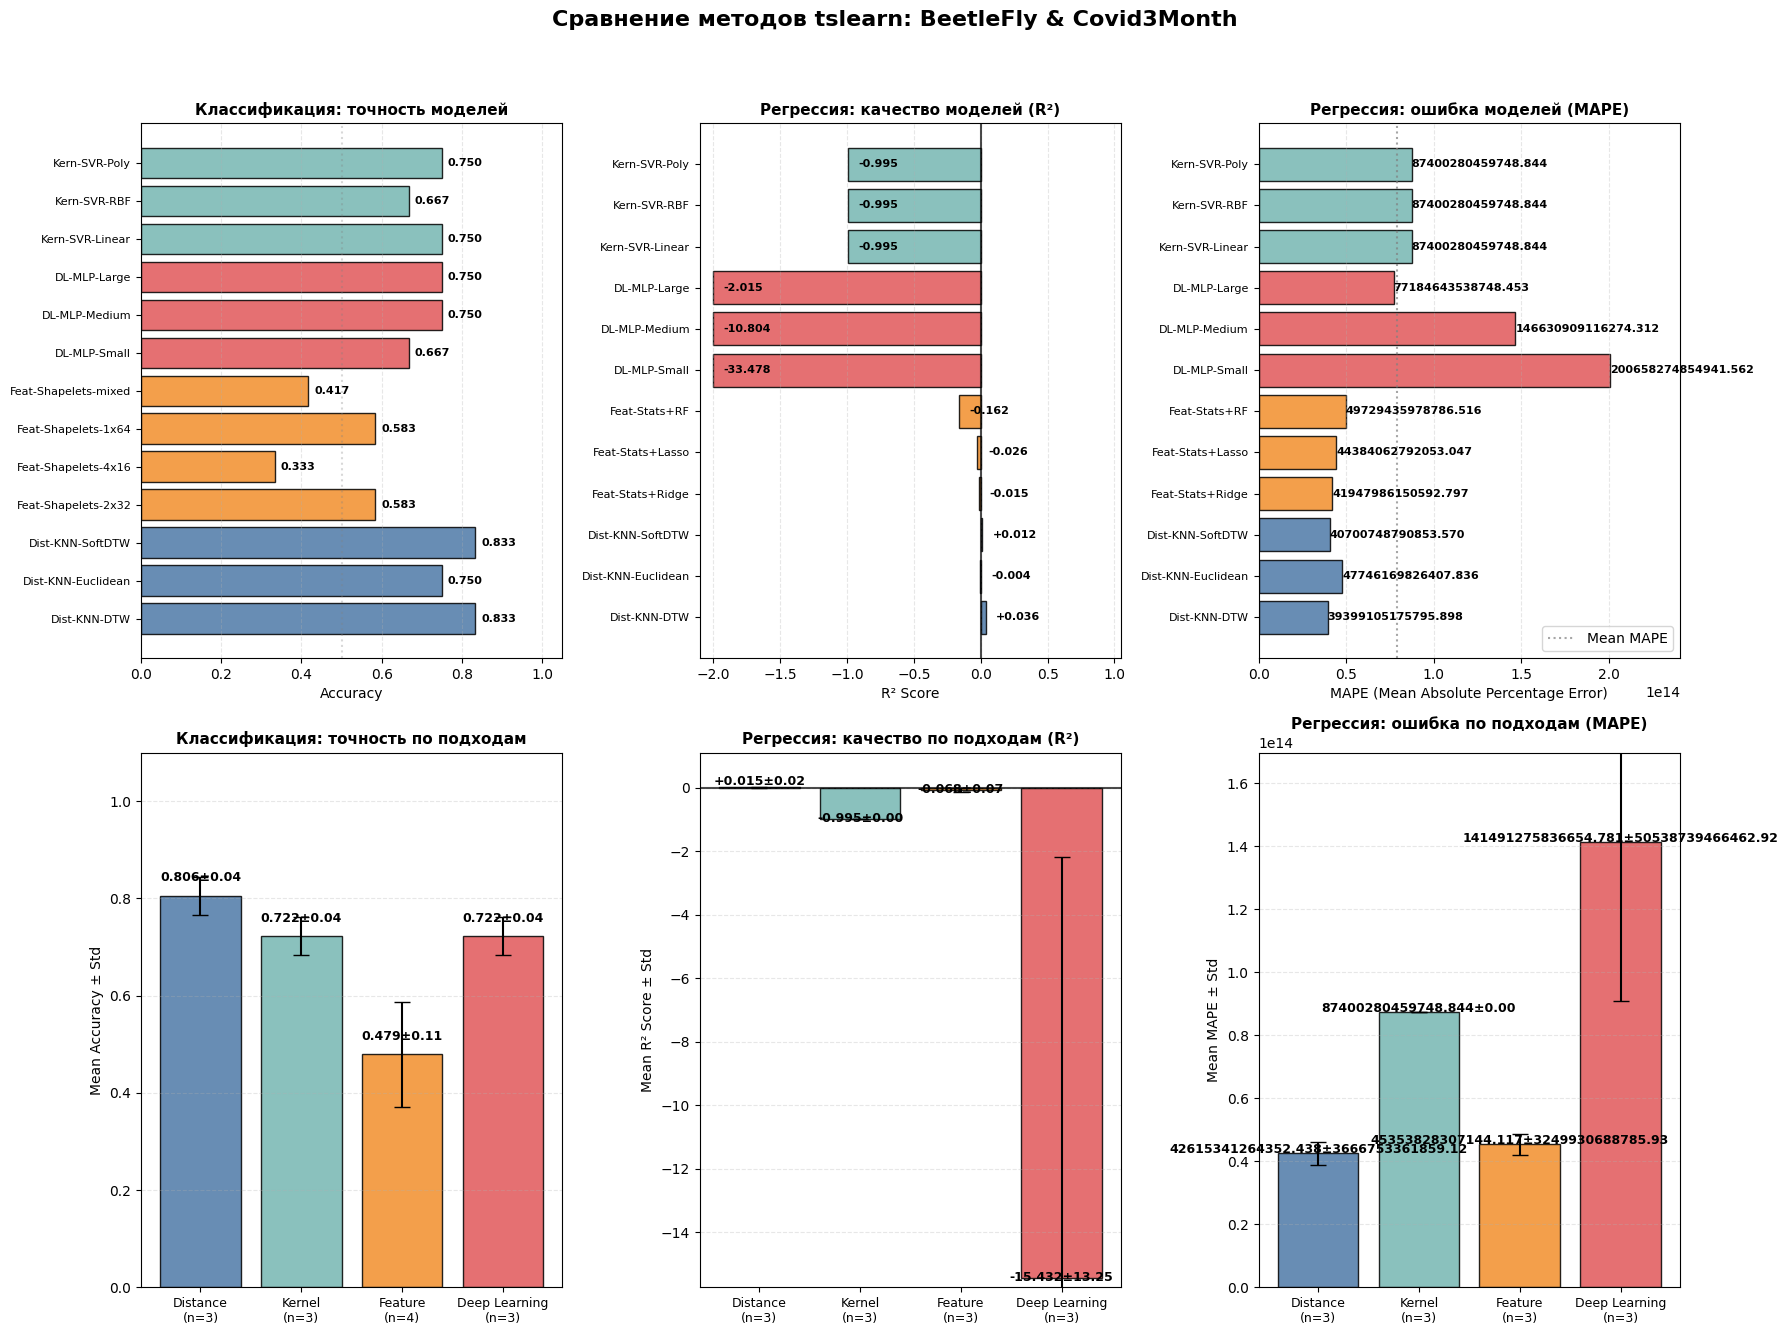


=== СТАТИСТИКА ДЛЯ DEEP LEARNING (регрессия) ===
Модель                                        :       R² |          MSE |       MAPE
-------------------------------------------------------------------------------------
DL-MLP-Large                                  :  -2.0153 |       0.0065 | 77184643538748.4531
DL-MLP-Medium                                 : -10.8038 |       0.0255 | 146630909116274.3125
DL-MLP-Small                                  : -33.4779 |       0.0746 | 200658274854941.5625

=== ПРОВЕРКА ДАННЫХ ДЛЯ РЕГРЕССИИ ===
Форма X_reg_train:     (140, 84, 1)
Форма X_reg_test:      (61, 84, 1)
Диапазон y_reg_train:  [0.0000, 0.1578]
Диапазон y_reg_test:   [0.0000, 0.1818]
Среднее y_reg_train:   0.0401 ± 0.0391
Среднее y_reg_test:    0.0325 ± 0.0465
NaN в X_reg_train:     0
NaN в y_reg_train:     0

=== КРАТКИЕ ВЫВОДЫ ===
Лучшая модель классификации: Dist-KNN-DTW (Accuracy = 0.8333)
Лучший подход (классификация): Distance (средняя Accuracy = 0.8056)
Лучшая модель регрессии

In [132]:
results_cls = {}
results_cls.update({f"Dist-{k}": v for k, v in distance_cls.items() if v is not None})
results_cls.update({f"Feat-{k}": v for k, v in feature_cls.items() if v is not None})
results_cls.update({f"DL-{k}": v for k, v in mlp_cls.items() if v is not None})
results_cls.update({f"Kern-{k}": v for k, v in svm_cls.items() if v is not None})

results_reg = {}
results_reg.update({f"Dist-{k}": (v['R2'], v['MSE'], v['MAPE']) for k, v in distance_reg.items() if v is not None})
results_reg.update({f"Feat-{k}": (v['R2'], v['MSE'], v['MAPE']) for k, v in feature_reg.items() if v is not None})
results_reg.update({f"DL-{k}": (v['R2'], v['MSE'], v['MAPE']) for k, v in mlp_reg.items() if v is not None})
results_reg.update({f"Kern-{k}": (v['R2'], v['MSE'], v['MAPE']) for k, v in svm_reg.items() if v is not None})

print("\n" + "="*90)
print("=== СВОДНЫЕ РЕЗУЛЬТАТЫ КЛАССИФИКАЦИИ (accuracy) ===")
print("="*90)
if results_cls:
    sorted_results_cls = sorted(results_cls.items(), key=lambda x: x[1], reverse=True)
    print(f"{'Модель':<45s} : {'Accuracy':>10s}")
    print("-"*60)
    for model, acc in sorted_results_cls:
        print(f"{model:<45s} : {acc:>10.4f}")
else:
    print("Нет данных для отображения")

print("\n" + "="*90)
print("=== СВОДНЫЕ РЕЗУЛЬТАТЫ РЕГРЕССИИ (R², MSE, MAPE) ===")
print("="*90)
if results_reg:
    sorted_results_reg = sorted(results_reg.items(), key=lambda x: x[1][0], reverse=True)
    print(f"{'Модель':<45s} : {'R²':>10s} | {'MSE':>12s} | {'MAPE':>10s}")
    print("-"*85)
    for model, (r2, mse, mape) in sorted_results_reg:
        print(f"{model:<45s} : {r2:>+10.4f} | {mse:>12.4f} | {mape:>10.4f}")
else:
    print("Нет данных для отображения")


fig = plt.figure(figsize=(18, 14))
fig.suptitle('Сравнение методов tslearn: BeetleFly & Covid3Month', fontsize=16, fontweight='bold')

def get_color(model_name):
    if 'Dist' in model_name: return '#4E79A7'
    elif 'Kern' in model_name: return '#76B7B2'
    elif 'Feat' in model_name: return '#F28E2B'
    elif 'DL' in model_name: return '#E15759'
    else: return '#9C755F'

ax1 = plt.subplot(2, 3, 1)
if results_cls:
    models_cls = list(results_cls.keys())
    accuracies = list(results_cls.values())
    colors = [get_color(m) for m in models_cls]
    
    y_pos = np.arange(len(models_cls))
    bars = ax1.barh(y_pos, accuracies, color=colors, edgecolor='black', alpha=0.85)
    ax1.set_yticks(y_pos)
    ax1.set_yticklabels(models_cls, fontsize=8)
    ax1.set_xlabel('Accuracy', fontsize=10)
    ax1.set_title('Классификация: точность моделей', fontsize=11, fontweight='bold')
    ax1.set_xlim(0, 1.05)
    ax1.grid(axis='x', alpha=0.3, linestyle='--')
    ax1.axvline(x=0.5, color='gray', linestyle=':', alpha=0.3)
    
    for bar, acc in zip(bars, accuracies):
        ax1.text(bar.get_width() + 0.015, bar.get_y() + bar.get_height()/2, 
                 f'{acc:.3f}', va='center', fontsize=8, fontweight='bold')
else:
    ax1.text(0.5, 0.5, 'Нет данных', ha='center', va='center', transform=ax1.transAxes)

ax2 = plt.subplot(2, 3, 2)
if results_reg:
    models_reg = list(results_reg.keys())
    r2_scores = [results_reg[m][0] for m in models_reg]
    r2_plot = [max(min(r2, 1.0), -2.0) for r2 in r2_scores]
    colors = [get_color(m) for m in models_reg]
    
    y_pos = np.arange(len(models_reg))
    bars = ax2.barh(y_pos, r2_plot, color=colors, edgecolor='black', alpha=0.85)
    ax2.set_yticks(y_pos)
    ax2.set_yticklabels(models_reg, fontsize=8)
    ax2.set_xlabel('R² Score', fontsize=10)
    ax2.set_title('Регрессия: качество моделей (R²)', fontsize=11, fontweight='bold')
    ax2.set_xlim(-2.1, 1.05)
    ax2.grid(axis='x', alpha=0.3, linestyle='--')
    ax2.axvline(x=0, color='black', linestyle='-', linewidth=1.5, alpha=0.7)
    
    for bar, r2_orig in zip(bars, r2_scores):
        text_x = bar.get_width() + 0.08 if bar.get_width() < 0.9 else bar.get_width() - 0.15
        color_text = 'white' if bar.get_width() > 0.5 else 'black'
        ax2.text(text_x, bar.get_y() + bar.get_height()/2, 
                 f'{r2_orig:+.3f}', va='center', fontsize=8, fontweight='bold', color=color_text)
else:
    ax2.text(0.5, 0.5, 'Нет данных', ha='center', va='center', transform=ax2.transAxes)

ax3 = plt.subplot(2, 3, 3)
if results_reg:
    models_reg = list(results_reg.keys())
    mape_scores = [results_reg[m][2] for m in models_reg]
    colors = [get_color(m) for m in models_reg]
    
    y_pos = np.arange(len(models_reg))
    bars = ax3.barh(y_pos, mape_scores, color=colors, edgecolor='black', alpha=0.85)
    ax3.set_yticks(y_pos)
    ax3.set_yticklabels(models_reg, fontsize=8)
    ax3.set_xlabel('MAPE (Mean Absolute Percentage Error)', fontsize=10)
    ax3.set_title('Регрессия: ошибка моделей (MAPE)', fontsize=11, fontweight='bold')
    ax3.set_xlim(0, max(mape_scores)*1.2 if mape_scores else 1) 
    ax3.grid(axis='x', alpha=0.3, linestyle='--')
    ax3.axvline(x=np.mean(mape_scores), color='gray', linestyle=':', label='Mean MAPE', alpha=0.7)
    
    for bar, mape in zip(bars, mape_scores):
        ax3.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
                 f'{mape:.3f}', va='center', fontsize=8, fontweight='bold')
    ax3.legend(loc='lower right')
else:
    ax3.text(0.5, 0.5, 'Нет данных', ha='center', va='center', transform=ax3.transAxes)

ax4 = plt.subplot(2, 3, 4)
approaches_cls = {'Distance': [], 'Kernel': [], 'Feature': [], 'Deep Learning': []}
for model, acc in results_cls.items():
    if 'Dist' in model: approaches_cls['Distance'].append(acc)
    elif 'Kern' in model: approaches_cls['Kernel'].append(acc)
    elif 'Feat' in model: approaches_cls['Feature'].append(acc)
    elif 'DL' in model: approaches_cls['Deep Learning'].append(acc)

approach_names = list(approaches_cls.keys())
approach_means = [np.mean(approaches_cls[a]) if approaches_cls[a] else np.nan for a in approach_names]
approach_stds = [np.std(approaches_cls[a]) if len(approaches_cls[a]) > 1 else 0 for a in approach_names]
approach_counts = [len(approaches_cls[a]) for a in approach_names]

x_pos = np.arange(len(approach_names))
colors_approach = ['#4E79A7', '#76B7B2', '#F28E2B', '#E15759']
bars = ax4.bar(x_pos, approach_means, yerr=approach_stds, capsize=6, 
               color=colors_approach, edgecolor='black', alpha=0.85)
ax4.set_xticks(x_pos)
ax4.set_xticklabels([f'{n}\n(n={c})' for n, c in zip(approach_names, approach_counts)], fontsize=9)
ax4.set_ylabel('Mean Accuracy ± Std', fontsize=10)
ax4.set_title('Классификация: точность по подходам', fontsize=11, fontweight='bold')
ax4.set_ylim(0, 1.1)
ax4.grid(axis='y', alpha=0.3, linestyle='--')

for bar, mean, std in zip(bars, approach_means, approach_stds):
    if not np.isnan(mean):
        ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03, 
                 f'{mean:.3f}±{std:.2f}', ha='center', fontsize=9, fontweight='bold')

ax5 = plt.subplot(2, 3, 5)
approaches_reg_r2 = {'Distance': [], 'Kernel': [], 'Feature': [], 'Deep Learning': []}
for model, (r2, _, _) in results_reg.items():
    if 'Dist' in model: approaches_reg_r2['Distance'].append(r2)
    elif 'Kern' in model: approaches_reg_r2['Kernel'].append(r2)
    elif 'Feat' in model: approaches_reg_r2['Feature'].append(r2)
    elif 'DL' in model: approaches_reg_r2['Deep Learning'].append(r2)

approach_means_r2 = [np.mean(approaches_reg_r2[a]) if approaches_reg_r2[a] else np.nan for a in approach_names]
approach_stds_r2 = [np.std(approaches_reg_r2[a]) if len(approaches_reg_r2[a]) > 1 else 0 for a in approach_names]
counts_reg = [len(approaches_reg_r2[a]) for a in approach_names]

bars = ax5.bar(x_pos, approach_means_r2, yerr=approach_stds_r2, capsize=6,
               color=colors_approach, edgecolor='black', alpha=0.85)
ax5.set_xticks(x_pos)
ax5.set_xticklabels([f'{n}\n(n={c})' for n, c in zip(approach_names, counts_reg)], fontsize=9)
ax5.set_ylabel('Mean R² Score ± Std', fontsize=10)
ax5.set_title('Регрессия: качество по подходам (R²)', fontsize=11, fontweight='bold')
y_min_r2 = min([m for m in approach_means_r2 if not np.isnan(m)] + [0]) - 0.3 if any(not np.isnan(m) for m in approach_means_r2) else -1
ax5.set_ylim(y_min_r2, 1.1)
ax5.grid(axis='y', alpha=0.3, linestyle='--')
ax5.axhline(y=0, color='black', linestyle='-', linewidth=1.5, alpha=0.7)

for bar, mean, std in zip(bars, approach_means_r2, approach_stds_r2):
    if not np.isnan(mean):
        y_pos_text = bar.get_height() + 0.05 if mean >= 0 else bar.get_height() - 0.1
        ax5.text(bar.get_x() + bar.get_width()/2, y_pos_text, 
                 f'{mean:+.3f}±{std:.2f}', ha='center', fontsize=9, fontweight='bold')

ax6 = plt.subplot(2, 3, 6)
approaches_reg_mape = {'Distance': [], 'Kernel': [], 'Feature': [], 'Deep Learning': []}
for model, (_, _, mape) in results_reg.items():
    if 'Dist' in model: approaches_reg_mape['Distance'].append(mape)
    elif 'Kern' in model: approaches_reg_mape['Kernel'].append(mape)
    elif 'Feat' in model: approaches_reg_mape['Feature'].append(mape)
    elif 'DL' in model: approaches_reg_mape['Deep Learning'].append(mape)

approach_means_mape = [np.mean(approaches_reg_mape[a]) if approaches_reg_mape[a] else np.nan for a in approach_names]
approach_stds_mape = [np.std(approaches_reg_mape[a]) if len(approaches_reg_mape[a]) > 1 else 0 for a in approach_names]

bars = ax6.bar(x_pos, approach_means_mape, yerr=approach_stds_mape, capsize=6,
               color=colors_approach, edgecolor='black', alpha=0.85)
ax6.set_xticks(x_pos)
ax6.set_xticklabels([f'{n}\n(n={c})' for n, c in zip(approach_names, counts_reg)], fontsize=9)
ax6.set_ylabel('Mean MAPE ± Std', fontsize=10)
ax6.set_title('Регрессия: ошибка по подходам (MAPE)', fontsize=11, fontweight='bold')
ax6.set_ylim(0, max([m for m in approach_means_mape if not np.isnan(m)] or [1]) * 1.2)
ax6.grid(axis='y', alpha=0.3, linestyle='--')

for bar, mean, std in zip(bars, approach_means_mape, approach_stds_mape):
    if not np.isnan(mean):
        ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                 f'{mean:.3f}±{std:.2f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


print("\n" + "="*90)
print("=== СТАТИСТИКА ДЛЯ DEEP LEARNING (регрессия) ===")
print("="*90)
dl_reg_models = [(m, r2, mse, mape) for m, (r2, mse, mape) in results_reg.items() if 'DL-' in m]
if dl_reg_models:
    print(f"{'Модель':<45s} : {'R²':>8s} | {'MSE':>12s} | {'MAPE':>10s}")
    print("-"*85)
    for model, r2, mse, mape in sorted(dl_reg_models, key=lambda x: x[1], reverse=True):
        print(f"{model:<45s} : {r2:+8.4f} | {mse:12.4f} | {mape:10.4f}")
else:
    print("Нет результатов для Deep Learning регрессии")


print("\n" + "="*90)
print("=== ПРОВЕРКА ДАННЫХ ДЛЯ РЕГРЕССИИ ===")
print("="*90)
try:
    print(f"Форма X_reg_train:     {X_reg_train.shape}")
    print(f"Форма X_reg_test:      {X_reg_test.shape}")
    print(f"Диапазон y_reg_train:  [{y_reg_train.min():.4f}, {y_reg_train.max():.4f}]")
    print(f"Диапазон y_reg_test:   [{y_reg_test.min():.4f}, {y_reg_test.max():.4f}]")
    print(f"Среднее y_reg_train:   {y_reg_train.mean():.4f} ± {y_reg_train.std():.4f}")
    print(f"Среднее y_reg_test:    {y_reg_test.mean():.4f} ± {y_reg_test.std():.4f}")
    print(f"NaN в X_reg_train:     {np.isnan(X_reg_train).sum()}")
    print(f"NaN в y_reg_train:     {np.isnan(y_reg_train).sum()}")
except NameError:
    print("Переменные данных (X_reg_train, etc.) не найдены в текущей области видимости.")


print("\n" + "="*90)
print("=== КРАТКИЕ ВЫВОДЫ ===")
print("="*90)

if results_cls:
    best_cls = max(results_cls.items(), key=lambda x: x[1])
    print(f"Лучшая модель классификации: {best_cls[0]} (Accuracy = {best_cls[1]:.4f})")
    
    approach_scores_cls = {}
    for model, acc in results_cls.items():
        approach = 'Distance' if 'Dist' in model else 'Kernel' if 'Kern' in model else 'Feature' if 'Feat' in model else 'Deep Learning'
        approach_scores_cls.setdefault(approach, []).append(acc)
    best_approach_cls = max(approach_scores_cls.items(), key=lambda x: np.mean(x[1]))
    print(f"Лучший подход (классификация): {best_approach_cls[0]} (средняя Accuracy = {np.mean(best_approach_cls[1]):.4f})")

if results_reg:
    # Лучшая по R²
    best_reg_r2 = max(results_reg.items(), key=lambda x: x[1][0])
    print(f"Лучшая модель регрессии (по R²): {best_reg_r2[0]} (R² = {best_reg_r2[1][0]:+.4f}, MSE = {best_reg_r2[1][1]:.4f}, MAPE = {best_reg_r2[1][2]:.4f})")
    
    # Лучшая по MAPE (минимальная ошибка)
    best_reg_mape = min(results_reg.items(), key=lambda x: x[1][2])
    print(f"Лучшая модель регрессии (по MAPE): {best_reg_mape[0]} (MAPE = {best_reg_mape[1][2]:.4f}, R² = {best_reg_mape[1][0]:+.4f})")
    
    # Анализ подходов по R²
    approach_scores_reg_r2 = {}
    for model, (r2, _, _) in results_reg.items():
        approach = 'Distance' if 'Dist' in model else 'Kernel' if 'Kern' in model else 'Feature' if 'Feat' in model else 'Deep Learning'
        approach_scores_reg_r2.setdefault(approach, []).append(r2)
    best_approach_reg_r2 = max(approach_scores_reg_r2.items(), key=lambda x: np.mean(x[1]))
    print(f"Лучший подход (регрессия, R²): {best_approach_reg_r2[0]} (средний R² = {np.mean(best_approach_reg_r2[1]):+.4f})")

    # Анализ подходов по MAPE
    approach_scores_reg_mape = {}
    for model, (_, _, mape) in results_reg.items():
        approach = 'Distance' if 'Dist' in model else 'Kernel' if 'Kern' in model else 'Feature' if 'Feat' in model else 'Deep Learning'
        approach_scores_reg_mape.setdefault(approach, []).append(mape)
    best_approach_reg_mape = min(approach_scores_reg_mape.items(), key=lambda x: np.mean(x[1]))
    print(f"Лучший подход (регрессия, MAPE): {best_approach_reg_mape[0]} (средний MAPE = {np.mean(best_approach_reg_mape[1]):.4f})")